In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

In [2]:
# Read data, here r^2 values for Tahoe confidence between ML and no ML conditions
df1 = pd.read_csv('protein_mlp_r2.csv')
df2 = pd.read_csv('protein_mlp_r2_noml.csv')

In [3]:
# Merge and calculate r^2 difference
merged = df1.merge(df2, on='protein', how='left').dropna()
merged['r2_diff'] = merged['r2_x'] - merged['r2_y']

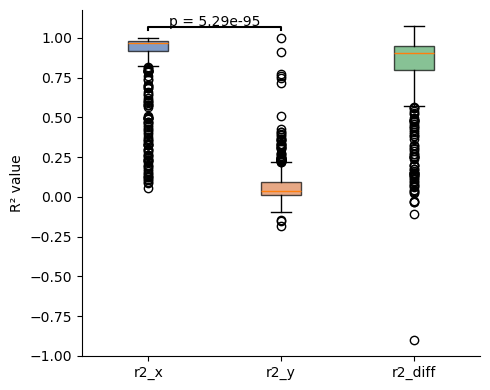

In [4]:
# Plotting

# Data 
x = merged['r2_x'].dropna()
y = merged['r2_y'].dropna()

# align indices (important for paired test)
common_idx = x.index.intersection(y.index)
x = x.loc[common_idx]
y = y.loc[common_idx]

#  Stats
stat, p = wilcoxon(x, y)

# format p-value
if p < 1e-300:
    p_str = "<1e-300"
else:
    p_str = f"{p:.2e}"

# Make plot
plt.figure(figsize=(5,4))

data = [x, y, merged['r2_diff'].dropna()]
labels = ['r2_x', 'r2_y', 'r2_diff']

# Set colors
colors = ['#4C72B0', '#DD8452', '#55A868']  # blue, orange, green

box = plt.boxplot(data, patch_artist=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Significance bar (between r2_x and r2_y)
y_max = max(np.max(x), np.max(y))
y_line = y_max + 0.05

plt.plot([1, 1, 2, 2], [y_line, y_line+0.02, y_line+0.02, y_line], color='black')
plt.text(1.5, y_line+0.025, f"p = {p_str}", ha='center')

# Formatting
plt.xticks([1,2,3], labels)
plt.ylabel('R² value')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show plot
plt.tight_layout()
plt.show()